# LieselOptim: basic optimization

This notebook introduces `LieselOptim` with a single-sample-size Gaussian regression model. We first fit the model with full-data L-BFGS. Then we add a train/validation/test split, use validation loss for early stopping, switch to mini-batches, and optimize with Adam.

## Imports

In [1]:
import logging

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax
import pandas as pd
import tensorflow_probability.substrates.jax.distributions as tfd

import liesel.experimental.optim as opt
import liesel.model as lsl

logging.getLogger("liesel.model.model").setLevel(logging.WARNING)
pd.options.display.float_format = "{:.3f}".format

## Simulate one data set

The response `y` and design matrix `X` both use axis `0` as their observation axis. This is the simplest case for splitting and batching because every observed array has the same sample size.

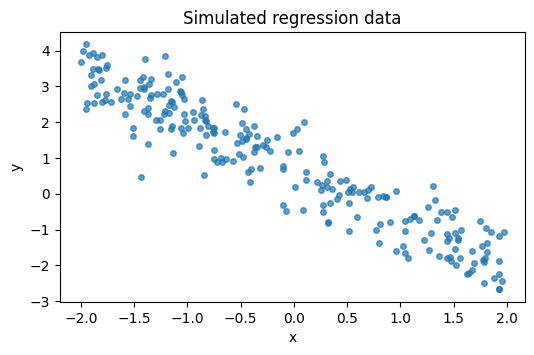

In [2]:
rng = np.random.default_rng(202405)

n = 240
x = rng.uniform(-2.0, 2.0, size=n).astype("float32")
X = np.column_stack([np.ones(n, dtype="float32"), x]).astype("float32")

beta_true = np.array([0.7, -1.4], dtype="float32")
sigma_true = np.float32(0.6)
y = (X @ beta_true + rng.normal(scale=sigma_true, size=n)).astype("float32")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.scatter(x, y, s=16, alpha=0.7)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Simulated regression data")
plt.show()

## Build the model

The model has two optimized parameters: a vector of regression coefficients `beta` and the unconstrained scale parameter `log_sigma`. The standard deviation used in the likelihood is `sigma = exp(log_sigma)`.

In [3]:
X_jax = jnp.asarray(X)
y_jax = jnp.asarray(y)

beta = lsl.Var.new_param(
    jnp.zeros(X_jax.shape[1]),
    lsl.Dist(tfd.Normal, loc=0.0, scale=5.0),
    name="beta",
)
log_sigma = lsl.Var.new_param(
    jnp.array(0.0),
    lsl.Dist(tfd.Normal, loc=0.0, scale=1.0),
    name="log_sigma",
)
sigma = lsl.Var.new_calc(jnp.exp, log_sigma, name="sigma")

X_var = lsl.Var.new_obs(X_jax, name="X")
mu = lsl.Var.new_calc(lambda X, beta: X @ beta, X_var, beta, name="mu")
y_var = lsl.Var.new_obs(
    y_jax,
    lsl.Dist(tfd.Normal, loc=mu, scale=sigma),
    name="y",
)

model = lsl.Model([y_var])
{
    "parameters": list(model.parameters),
    "observed": list(model.observed),
}

{'parameters': ['log_sigma', 'beta'], 'observed': ['X', 'y']}

## Full-data optimization with L-BFGS

The shortest path is to pass the model to `LieselOptim`, choose the built-in `"lbfgs"` optimizer, and call `fit()`. Here we build the engine first so we can turn off the progress bar in the notebook output.

In [4]:
lbfgs_engine = opt.LieselOptim(
    model,
    optimizers="lbfgs",
    stopper=opt.Stopper(epochs=40, patience=8, rtol=1e-6),
    seed=1,
).build_engine()
lbfgs_engine.show_progress = False

result_lbfgs = lbfgs_engine.fit()
result_lbfgs

OptimResult(final_epoch=14, best_epoch=7, duration=0.7s)

In [5]:
pd.DataFrame(
    {
        "parameter": ["beta[0]", "beta[1]", "sigma"],
        "estimate": [
            float(result_lbfgs.best_position["beta"][0]),
            float(result_lbfgs.best_position["beta"][1]),
            float(jnp.exp(result_lbfgs.best_position["log_sigma"])),
        ],
        "truth": [float(beta_true[0]), float(beta_true[1]), float(sigma_true)],
    }
)

,parameter,estimate,truth
0,beta[0],0.699,0.700
1,beta[1],-1.372,-1.400
2,sigma,0.579,0.600


The returned `OptimResult` stores loss histories and the selected parameter position. With the default engine setting, `best_position` is restored from the best validation loss. Since this first run has no separate validation split, the training loss is used as the stopping monitor. The result object also provides plotting helpers for the loss and saved parameter paths.

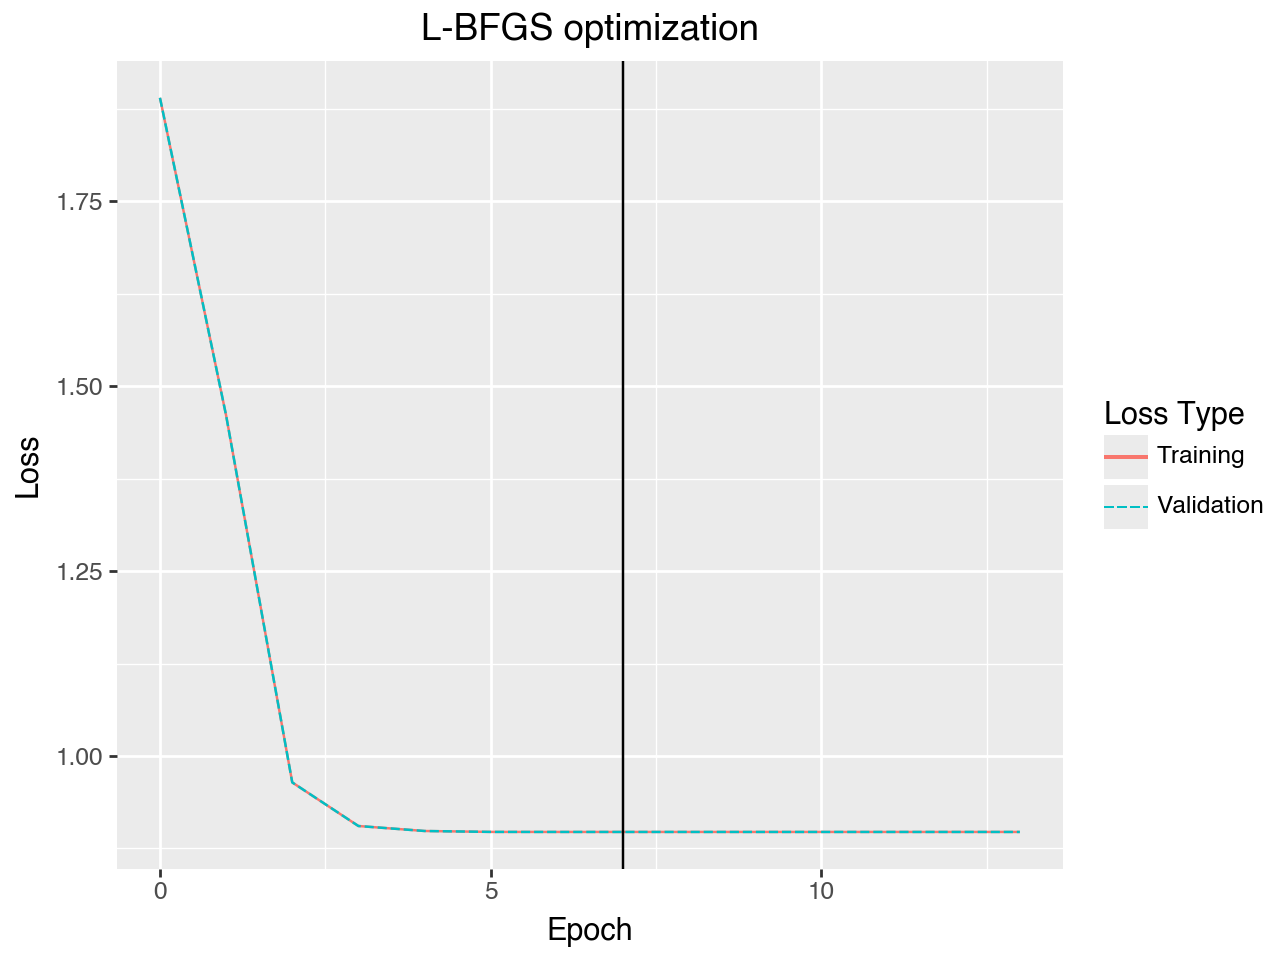

In [6]:
result_lbfgs.plot_loss(title="L-BFGS optimization")

## Add a train/validation/test split

`LieselOptim` optimizes parameters, but splitting and batching are done on observed entries. For this model, both `X` and `y` must be split together so that every response row keeps the matching design-matrix row.

In [7]:
split = opt.PositionSplit.from_model(
    model,
    position_keys=["X", "y"],
    share_validate=0.2,
    share_test=0.1,
    shuffle=True,
    seed=11,
)

split

PositionSplit(train=168, validate=48, test=24)

The validation split is now used for early stopping. The test split is never touched by the optimizer; we keep it for a final predictive check.

## Mini-batches and Adam

For stochastic optimization we switch from L-BFGS to Adam and pass `batch_size`. The default negative log-probability loss rescales the mini-batch likelihood to the training sample size.

In [8]:
adam_optimizer = opt.Optimizer(
    ["beta", "log_sigma"],
    optax.adam(learning_rate=1e-2),
    identifier="adam",
)

adam_engine = opt.LieselOptim(
    model,
    split=split,
    batch_size=32,
    optimizers=[adam_optimizer],
    stopper=opt.Stopper(epochs=250, patience=30, rtol=1e-4),
    seed=12,
).build_engine()
adam_engine.show_progress = False

{
    "batching": repr(adam_engine.batches),
    "n_full_batches": adam_engine.batches.n_full_batches,
    "validation": split.n_validate,
    "test": split.n_test,
}

{'batching': 'Batches(n=168, batch_size=32, default_axis=0)',
 'n_full_batches': 5,
 'validation': 48,
 'test': 24}

In [9]:
result_adam = adam_engine.fit()
result_adam

OptimResult(final_epoch=109, best_epoch=79, duration=0.3s)

In [10]:
pd.DataFrame(
    {
        "parameter": ["beta[0]", "beta[1]", "sigma"],
        "estimate": [
            float(result_adam.best_position["beta"][0]),
            float(result_adam.best_position["beta"][1]),
            float(jnp.exp(result_adam.best_position["log_sigma"])),
        ],
        "truth": [float(beta_true[0]), float(beta_true[1]), float(sigma_true)],
    }
)

,parameter,estimate,truth
0,beta[0],0.706,0.700
1,beta[1],-1.365,-1.400
2,sigma,0.592,0.600


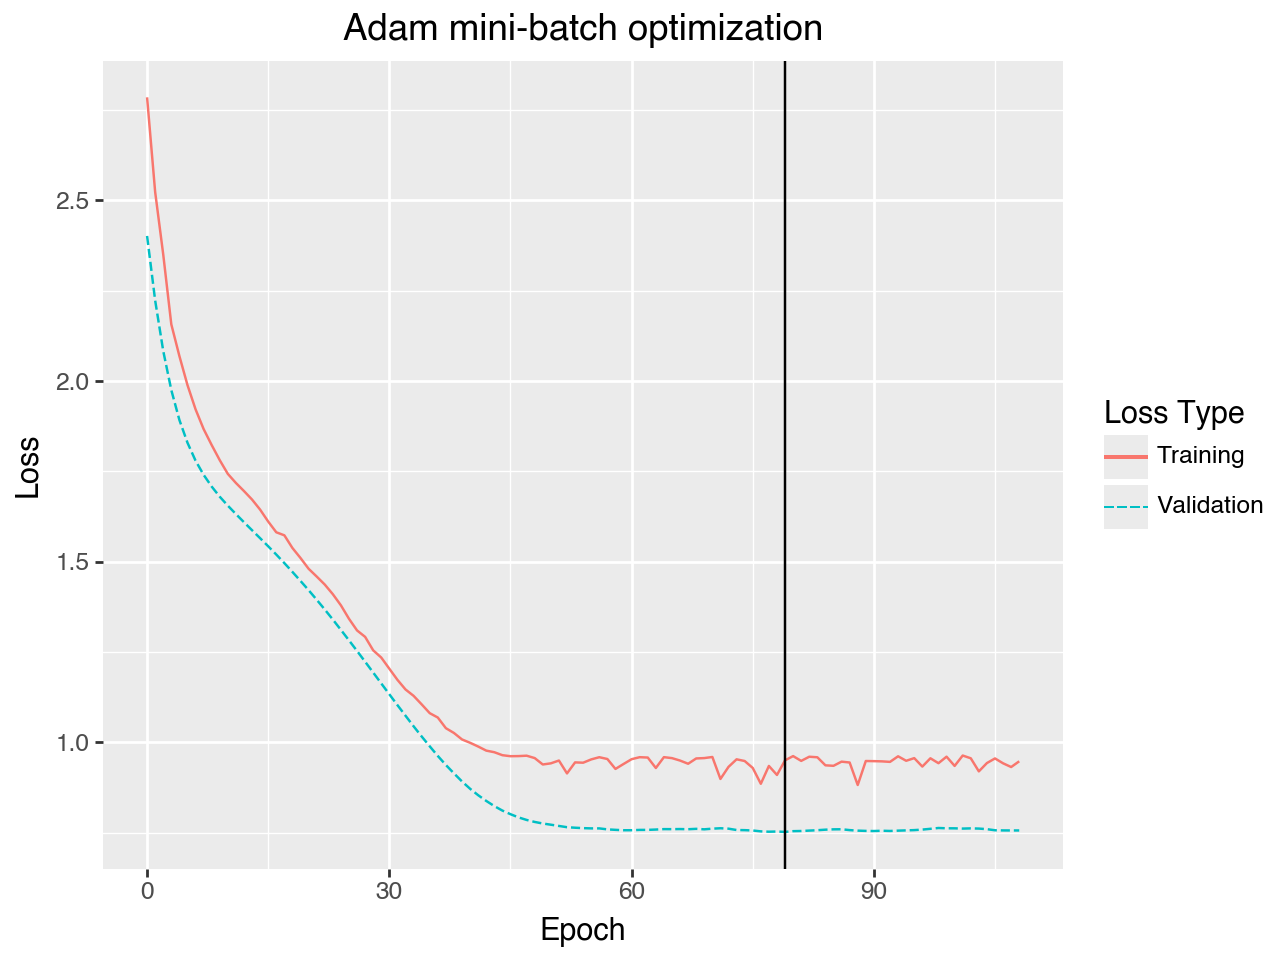

In [11]:
result_adam.plot_loss(title="Adam mini-batch optimization")

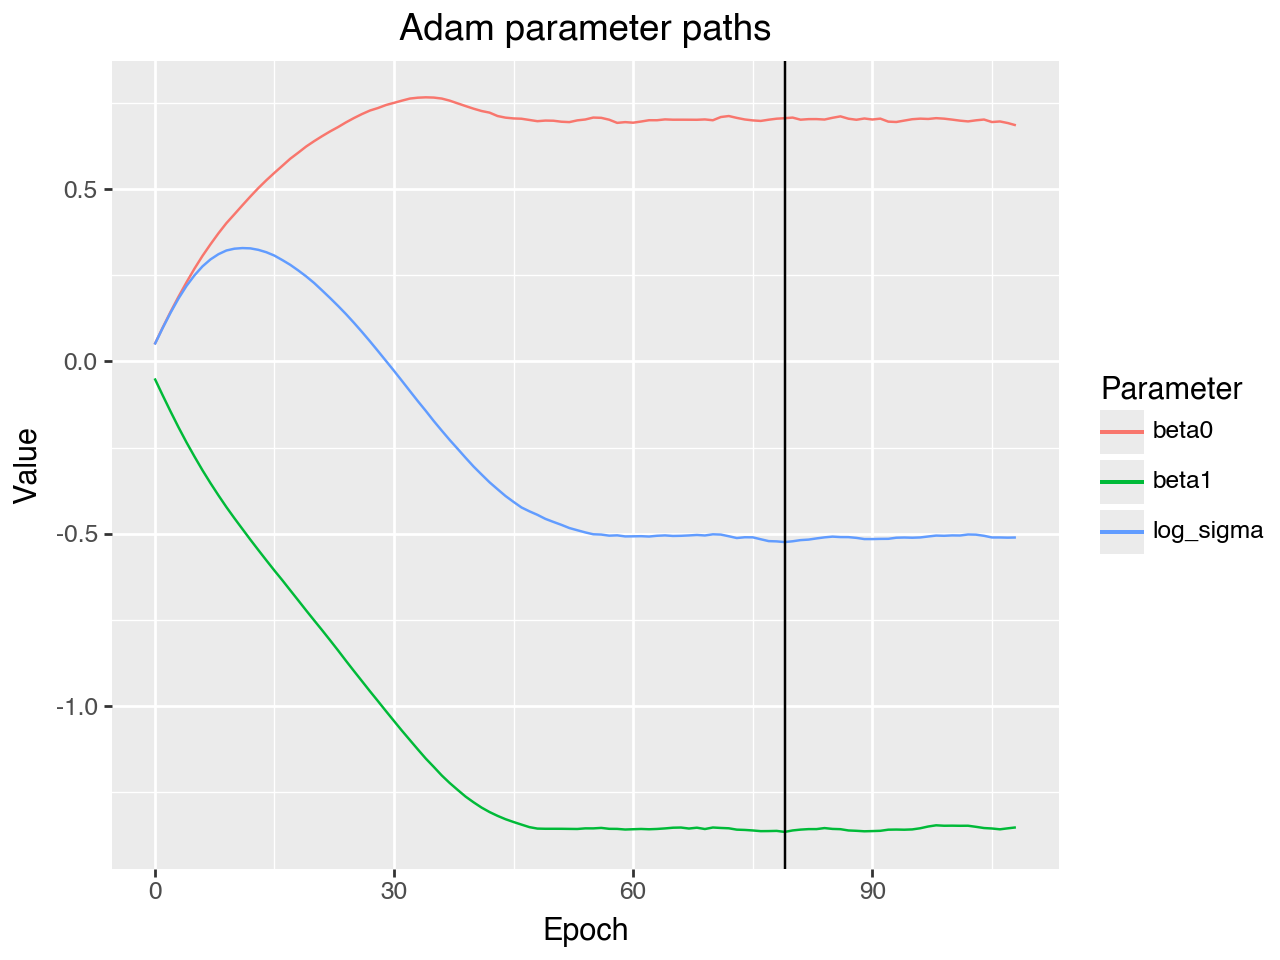

In [12]:
result_adam.plot_params(
    title="Adam parameter paths",
    subset=["beta", "log_sigma"],
)

## Evaluate on held-out test data

The helper below evaluates the scaled test log likelihood at a fitted position. For the single-size case, dividing by `split.n_train` gives a per-observation quantity on the same scale as the default `scale_loss="auto"` training loss. The earlier L-BFGS fit intentionally used all rows, so the held-out check is for the split-aware Adam run.

In [13]:
test_state = model.update_state(result_adam.best_position | split.test, model.state)
test_loss = float(-split.scaled_log_lik(model, test_state, part="test") / split.n_train)

pd.DataFrame(
    {
        "fit": ["Adam mini-batch"],
        "best_epoch": [result_adam.best_epoch],
        "final_epoch": [result_adam.final_epoch],
        "test_loss": [test_loss],
    }
)

,fit,best_epoch,final_epoch,test_loss
0,Adam mini-batch,79,109,0.870


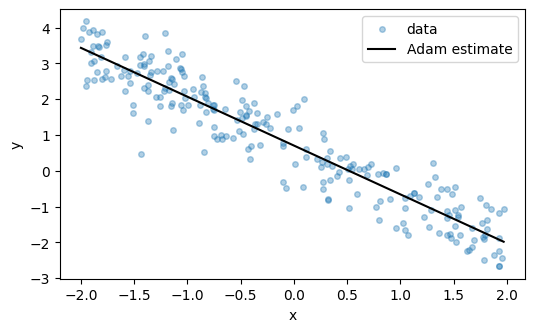

In [14]:
x_grid = np.linspace(x.min(), x.max(), 100, dtype="float32")
X_grid = np.column_stack([np.ones_like(x_grid), x_grid])
beta_hat = np.asarray(result_adam.best_position["beta"])
y_hat = X_grid @ beta_hat

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.scatter(x, y, s=16, alpha=0.35, label="data")
ax.plot(x_grid, y_hat, color="black", label="Adam estimate")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend()
plt.show()